In [12]:
import numpy as np
X = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=np.float32)
y = np.array([[0],[1],[1],[0]], dtype=np.float32)


In [13]:
# Keras implementation
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

tf.random.set_seed(42)

model = tf.keras.Sequential([
    tf.keras.layers.Dense(3, activation='tanh', input_shape=(2,)),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.05),
    loss='binary_crossentropy'
)
history_keras = model.fit(X, y, epochs=1500, verbose=0)

preds_keras = model.predict(X, verbose=0).reshape(-1,1)
print("Keras predictions (probabilities):")
for inp, p in zip(X, preds_keras):
    print(f"{inp} -> {p[0]:.4f} -> rounded {int(p[0]>0.5)}")

losses_keras = history_keras.history['loss']


g:\My Drive\Sem 3\Deep Learning\DL Lab\venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Keras predictions (probabilities):
[0. 0.] -> 0.0003 -> rounded 0
[0. 1.] -> 0.9998 -> rounded 1
[1. 0.] -> 0.9998 -> rounded 1
[1. 1.] -> 0.0006 -> rounded 0


In [14]:
# PyTorch implementation
import torch
import torch.nn as nn
import torch.optim as optim

torch.manual_seed(42)

X_t = torch.tensor(X)  
y_t = torch.tensor(y)  

class XORNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(2, 5)
        self.act = nn.LeakyReLU(negative_slope=0.1)
        self.fc2 = nn.Linear(5, 1)
    def forward(self, x):
        h = self.act(self.fc1(x))
        out = torch.sigmoid(self.fc2(h))
        return out

net = XORNet()
criterion = nn.BCELoss()
optimizer = optim.SGD(net.parameters(), lr=0.1, momentum=0.9)

losses_pytorch = []
for epoch in range(2000):
    optimizer.zero_grad()
    output = net(X_t)
    loss = criterion(output, y_t)
    loss.backward()
    optimizer.step()
    losses_pytorch.append(loss.item())

with torch.no_grad():
    preds_pt = net(X_t).numpy().reshape(-1,1)

print("PyTorch predictions (probabilities):")
for inp, p in zip(X, preds_pt):
    print(f"{inp} -> {p[0]:.6f} -> rounded {int(p[0]>0.5)}")


PyTorch predictions (probabilities):
[0. 0.] -> 0.000459 -> rounded 0
[0. 1.] -> 0.999783 -> rounded 1
[1. 0.] -> 0.999782 -> rounded 1
[1. 1.] -> 0.000175 -> rounded 0


In [15]:
# TensorFlow
import tensorflow as tf
tf.random.set_seed(7)

X_tf = tf.constant(X)
y_tf = tf.constant(y)

W1 = tf.Variable(tf.random.normal([2,2], stddev=0.5))
b1 = tf.Variable(tf.zeros([2]))
W2 = tf.Variable(tf.random.normal([2,1], stddev=0.5))
b2 = tf.Variable(tf.zeros([1]))

def forward(X):
    z1 = tf.matmul(X, W1) + b1      # shape (4,2)
    a1 = tf.math.tanh(z1)         # shape (4,2)
    z2 = tf.matmul(a1, W2) + b2   # shape (4,1)
    yhat = tf.sigmoid(z2)          # shape (4,1)
    return yhat, a1, z2

def bce_loss(y_true, y_pred):
    eps = 1e-8
    loss = - (y_true * tf.math.log(y_pred + eps) + (1 - y_true) * tf.math.log(1 - y_pred + eps))
    return tf.reduce_mean(loss)

opt = tf.optimizers.Adam(learning_rate=0.03)
losses_tf = []

for epoch in range(2500):
    with tf.GradientTape() as tape:
        yhat, a1, z2 = forward(X_tf)
        loss = bce_loss(y_tf, yhat)
    grads = tape.gradient(loss, [W1, b1, W2, b2])
    opt.apply_gradients(zip(grads, [W1, b1, W2, b2]))
    losses_tf.append(loss.numpy())

yhat_final, _, _ = forward(X_tf)
preds_tf = yhat_final.numpy().reshape(-1,1)

print("TensorFlow low-level predictions (probabilities):")
for inp, p in zip(X, preds_tf):
    print(f"{inp} -> {p[0]:.6f} -> rounded {int(p[0]>0.5)}")

TensorFlow low-level predictions (probabilities):
[0. 0.] -> 0.000114 -> rounded 0
[0. 1.] -> 0.999658 -> rounded 1
[1. 0.] -> 0.999657 -> rounded 1
[1. 1.] -> 0.000101 -> rounded 0


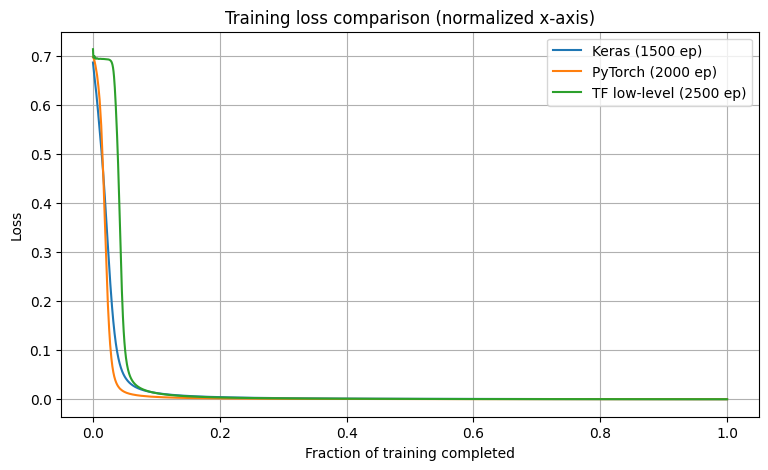

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9,5))
plt.plot(np.linspace(0,1,len(losses_keras)), losses_keras, label='Keras (1500 ep)')
plt.plot(np.linspace(0,1,len(losses_pytorch)), losses_pytorch, label='PyTorch (2000 ep)')
plt.plot(np.linspace(0,1,len(losses_tf)), losses_tf, label='TF low-level (2500 ep)')
plt.xlabel('Fraction of training completed')
plt.ylabel('Loss')
plt.title('Training loss comparison (normalized x-axis)')
plt.legend()
plt.grid(True)
plt.show()